In [1]:
import pandas as pd

from pathlib import Path

### Load Scores

In [2]:
exercise_path = Path("course_directory/ads_exercise")
output_path = Path("total_score")

In [3]:
scores = pd.read_csv(exercise_path.joinpath("grades.csv"))
scores.head()

,assignment,duedate,timestamp,student_id,last_name,first_name,email,raw_score,late_submission_penalty,score,max_score
0,04_python_basics_III,NaN,NaN,theresanadler,NaN,NaN,NaN,0.0,0.0,0.0,10.0
1,04_python_basics_III,NaN,NaN,moestenfau,NaN,NaN,NaN,0.0,0.0,0.0,10.0
2,04_python_basics_III,NaN,NaN,lucaabel,NaN,NaN,NaN,6.5,0.0,6.5,10.0
3,04_python_basics_III,NaN,NaN,moesten,NaN,NaN,NaN,0.0,0.0,0.0,10.0
4,04_python_basics_III,NaN,NaN,AhmedSofan10,NaN,NaN,NaN,8.0,0.0,8.0,10.0


In [4]:
score_long = scores.set_index(["student_id", "assignment"]).sort_index()
score_long

duedate  timestamp  last_name  first_name  \
student_id   assignment                                                        
AhmedSofan10 04_python_basics_III      NaN        NaN        NaN         NaN   
             05_dicts_classes          NaN        NaN        NaN         NaN   
             06_numpy_scipy            NaN        NaN        NaN         NaN   
             07_pandas                 NaN        NaN        NaN         NaN   
             08_statistics             NaN        NaN        NaN         NaN   
...                                    ...        ...        ...         ...   
yp69ejot     09-visualization          NaN        NaN        NaN         NaN   
             10-ml                     NaN        NaN        NaN         NaN   
             ads_assignment_1          NaN        NaN        NaN         NaN   
             ads_assignment_2          NaN        NaN        NaN         NaN   
             ads_assignment_3          NaN        NaN        NaN         NaN   

                                   email  raw_score  late_submission_penalty  \
student_id   assignment                                                        
AhmedSofan10 04_python_basics_III    NaN        8.0                      0.0   
             05_dicts_classes        NaN       13.0                      0.0   
             06_numpy_scipy          NaN       10.0                      0.0   
             07_pandas               NaN        9.0                      0.0   
             08_statistics           NaN       11.0                      0.0   
...                                  ...        ...                      ...   
yp69ejot     09-visualization        NaN       11.0                      0.0   
             10-ml                   NaN       17.0                      0.0   
             ads_assignment_1        NaN        1.0                      0.0   
             ads_assignment_2        NaN        8.0                      0.0   
             ads_assignment_3        NaN       10.0                      0.0   

                                   score  max_score  
student_id   assignment                              
AhmedSofan10 04_python_basics_III    8.0       10.0  
             05_dicts_classes       13.0       13.0  
             06_numpy_scipy         10.0       10.0  
             07_pandas               9.0       12.0  
             08_statistics          11.0       11.0  
...                                  ...        ...  
yp69ejot     09-visualization       11.0       11.0  
             10-ml                  17.0       19.0  
             ads_assignment_1        1.0        1.0  
             ads_assignment_2        8.0        8.0  
             ads_assignment_3       10.0       10.0  

[640 rows x 9 columns]

In [5]:
sum_points = score_long["score"].unstack("assignment").sum(axis=1)
sum_points

student_id
AhmedSofan10     92.0
ArefehRh         51.0
Ashikluffy        1.0
Chamutalcast      9.0
Dan-github16      1.0
                ...  
viranya31         1.0
vv88alias       104.0
xindiyu         101.0
youssafB          0.0
yp69ejot        101.0
Length: 64, dtype: float64

In [6]:
max_score = score_long.xs(score_long.index[0][0], level="student_id")["max_score"].sum() # select the first student
max_score

105.0

In [7]:
# set this manually, when the score is not right
max_score = 100.0

In [12]:
percentage = (sum_points / max_score) * 100 
percentage[percentage > 100] = 100
percentage = percentage.sort_values(ascending=False)

In [13]:
percentage.head(20)

student_id
yp69ejot             100.0
PaulaLim             100.0
xindiyu              100.0
vv88alias            100.0
raihansaa            100.0
nickrpr              100.0
ly87muro             100.0
Gschosi              100.0
lamteteeow           100.0
charlottewiebecke    100.0
AhmedSofan10          92.0
suchirasuresh         85.0
MakitaNdunguru        85.0
luzrch                82.0
sriboote              82.0
MichaelaHofmann       80.0
abdallaheid00         75.0
lucaabel              69.5
SusanneMa             66.5
theoneandvronly       62.0
dtype: float64

<Axes: >

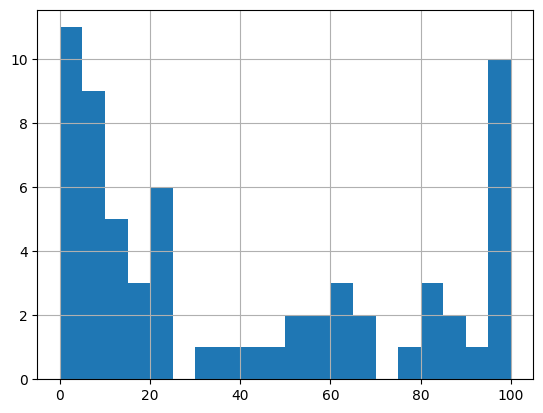

In [10]:
percentage.hist(bins=20)

In [14]:
import time

semester = "SoSe_23"

# export csv
timestr = time.strftime("%Y%m%d-%H%M%S")
percentage.to_csv(output_path.joinpath(semester+"-"+timestr+".csv"))